# Investigation 04: Specific Rules
This notebook evaluates a specific set of rules provided by the user, splitting the analysis (Consensus and Lift) by Organ and Stage. It dynamically handles functional markers and lineage subset matching.

In [ ]:
import ast
import os
import sys
sys.path.append(os.path.abspath('../../'))
from utils.rules import _extract_base_lineage

# --- Notebook config (no constants.py) ---
USE_FUNCTIONAL_MARKERS = False

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [ ]:
# ---------- Main toggles ----------
# Define the specific rules to look for. Each rule is a tuple: ({Antecedents}, {Consequents})
# It will match if the rule found in the results is a superset of these markers (or exact lineage if USE_FUNCTIONAL_MARKERS is False)
TARGET_RULES = [
    ({"Paneth"}, {"Epithelial_Ki67+"}),
    ({"Macrophage"}, {"Epithelial"}),
    ({"Plasma"}, {"Epithelial"}),
    ({"CD8T"}, {"Epithelial"}),
    # ({"CD8T_CD103+"}, {"Epithelial"}),
    # ({"CD8T_CD69+"}, {"Epithelial"}),
    ({"CD8T_GZMB+"}, {"Epithelial"}),
    # ({"Neutrophil_CD103+"}, {"Epithelial"}),
    ({"Neutrophil"}, {"Epithelial"}),
    ({"Macrophage"}, {"CD8T"}),
    ({"Endocrine"}, {"Muscle"}),
    ({"Fibroblast"}, {"Epithelial"})
]

STAGE_COLUMN = "Pathological score"  # "Pathological score", "Clinical score", "Pathological stage"

SUBSET_RULE_ITEMS_EQ = 2
SUBSET_MIN_SUPPORT = 0.0
MAX_FDR = 0.05

# ---------- Plot config ----------
FIG_SIZE = (18, 12)

# ---------- Data paths ----------
ALGO = "min_support_runs\weighted_fpgrowth_no_markers" 
# ALGO = "min_support_runs\weighted_fpgrowth_with_markers_2" 
# ALGO = "min_support_runs\weighted_fpgrowth_no_markers" 
DATA_ROOT = fr"results\full_run\{ALGO}\data"
# Change to the correct results CSV if needed
RAW_RESULTS_FILE = os.path.join('..', '..', DATA_ROOT, "results_CN.csv")


<>:29: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<>:29: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
C:\Users\Owner\AppData\Local\Temp\ipykernel_71436\3655907832.py:29: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
  ALGO = "min_support_runs\weighted_fpgrowth_with_markers_2"


## 1. Rule Matching Logic
Matches specific rule subsets according to `USE_FUNCTIONAL_MARKERS`

In [ ]:
def parse_item(item):
    parts = item.split('_')
    base = _extract_base_lineage(item)
    markers = {p for p in parts if p.endswith('+')}
    return base, markers

def item_matches(target_item, rule_item):
    if not USE_FUNCTIONAL_MARKERS:
        return _extract_base_lineage(target_item) == _extract_base_lineage(rule_item)
    
    t_base, t_markers = parse_item(target_item)
    r_base, r_markers = parse_item(rule_item)
    
    if t_base != r_base:
        return False
    return t_markers.issubset(r_markers)

def rule_matches(target_ant_set, target_con_set, rule_ant_list, rule_con_list):
    # For every item in target_ant, there must be at least one matching item in rule_ant
    for t_ant in target_ant_set:
        if not any(item_matches(t_ant, r_ant) for r_ant in rule_ant_list):
            return False
    for t_con in target_con_set:
        if not any(item_matches(t_con, r_con) for r_con in rule_con_list):
            return False
    return True


## 2. Load and Filter Data
Loads the raw results, attaches the Organ metadata, and keeps only rows that match `TARGET_RULES`.

In [ ]:
def load_and_filter_data(raw_results_file):
    if not os.path.exists(raw_results_file):
        print(f"File not found: {raw_results_file}")
        return pd.DataFrame()
        
    work_df = pd.read_csv(raw_results_file)
    work_df = work_df[work_df["FDR"] <= MAX_FDR].copy()
    
    # --- Standardized Organ Enrichment ---
    mibi_gut_dir_path = os.path.join("..", "..", "data", "MIBIGutCsv")
    biopsy_path = os.path.join(mibi_gut_dir_path, "biopsy_metadata.csv")
    fovs_path = os.path.join(mibi_gut_dir_path, "fovs_metadata.csv")
    
    if os.path.exists(biopsy_path) and os.path.exists(fovs_path):
        df_biopsy = pd.read_csv(biopsy_path)
        df_fovs = pd.read_csv(fovs_path)
        unique_biopsies = df_fovs[~df_fovs["FOV"].astype(str).str.startswith("S_")][["Patient", "Cohort"]].drop_duplicates().rename(columns={"Patient": "Biopsy_ID"})
        meta = pd.merge(unique_biopsies, df_biopsy[["Biopsy_ID", "Localization"]], on="Biopsy_ID", how="left")
        
        def get_organ(row):
            if pd.notna(row.get("Localization")): return row["Localization"]
            cohort = str(row.get("Cohort", ""))
            if "Colon" in cohort: return "Colon"
            if "Duodenum" in cohort: return "Duodenum"
            return "Unknown"
        
        meta["Organ"] = meta.apply(get_organ, axis=1)
        work_df = work_df.merge(meta[["Biopsy_ID", "Organ"]], on="Biopsy_ID", how="left")
    # -----------------------------------------------------------------------------

    # Clean rules
    work_df["ant_items"] = work_df["Antecedents"].apply(ast.literal_eval)
    work_df["con_items"] = work_df["Consequents"].apply(ast.literal_eval)
    work_df["ant_clean"] = work_df["ant_items"].apply(lambda items: [str(x).replace("_CENTER", "").replace("_NEIGHBOR", "") for x in items])
    work_df["con_clean"] = work_df["con_items"].apply(lambda items: [str(x).replace("_CENTER", "").replace("_NEIGHBOR", "") for x in items])
    
    # Filter by TARGET_RULES
    def matches_any_target(row):
        for target_ant, target_con in TARGET_RULES:
            if rule_matches(target_ant, target_con, row["ant_clean"], row["con_clean"]):
                return True
        return False
        
    # --- Calculate True Denominator BEFORE filtering rules ---
    # We must count total FOVs for each Organ/Stage now. If we count after filtering, 
    # FOVs that don't have any of the 11 target rules will be missing, inflating consensus.
    unique_stages_temp = work_df[STAGE_COLUMN].dropna().unique()
    if set(unique_stages_temp).issubset({"Control", "Mild", "Severe"}):
        order_temp = ["Control", "Mild", "Severe"]
        order_temp = [x for x in order_temp if x in unique_stages_temp]
    else:
        order_temp = sorted(unique_stages_temp)
    
    work_df[STAGE_COLUMN] = pd.Categorical(work_df[STAGE_COLUMN], categories=order_temp, ordered=True)
    global_fov_counts = work_df.groupby(["Organ", STAGE_COLUMN], observed=True)["FOV"].nunique().reset_index(name="Total_FOVs_In_Stage")
    
    # Optional subset filters (from NB 01)
    if SUBSET_RULE_ITEMS_EQ is not None:
        rule_item_count = work_df.apply(lambda row: len(row["ant_clean"]) + len(row["con_clean"]), axis=1)
        work_df = work_df[rule_item_count == int(SUBSET_RULE_ITEMS_EQ)].copy()

    if SUBSET_MIN_SUPPORT is not None:
        work_df = work_df[work_df["Support"] >= float(SUBSET_MIN_SUPPORT)].copy()

    # --- Filter to specific rules ---
    mask = work_df.apply(matches_any_target, axis=1)
    work_df = work_df[mask].copy()
    
    # --- Reattach the true denominator ---
    work_df = pd.merge(work_df, global_fov_counts, on=["Organ", STAGE_COLUMN], how="left")

    if work_df.empty:
        print("No rules matched the TARGET_RULES criteria.")
        return work_df

    # --- Marker Aggregation Logic ---
    target_markers = set()
    for ant_set, con_set in TARGET_RULES:
        for item in ant_set.union(con_set):
            _, markers = parse_item(item)
            target_markers.update(markers)

    def relabel_item(item):
        base, markers = parse_item(item)
        if not markers:
            return base
        kept_markers = [m for m in markers if m in target_markers]
        if not kept_markers:
            return base
        return f"{base}_{'_'.join(sorted(kept_markers))}"

    # Relabel the items in the dataframe to combine non-target markers
    work_df["ant_relabel"] = work_df["ant_clean"].apply(lambda items: [relabel_item(x) for x in items])
    work_df["con_relabel"] = work_df["con_clean"].apply(lambda items: [relabel_item(x) for x in items])

    # Build the final string for the plot
    work_df["Rule"] = work_df.apply(
        lambda row: f"{', '.join(row['ant_relabel'])} -> {', '.join(row['con_relabel'])}",
        axis=1,
    )

    unique_stages = work_df[STAGE_COLUMN].dropna().unique()
    if set(unique_stages).issubset({"Control", "Mild", "Severe"}):
        order = ["Control", "Mild", "Severe"]
        order = [x for x in order if x in unique_stages]
    else:
        order = sorted(unique_stages)
        
    work_df[STAGE_COLUMN] = pd.Categorical(
        work_df[STAGE_COLUMN],
        categories=order,
        ordered=True
    )
    
    return work_df

filtered_df = load_and_filter_data(RAW_RESULTS_FILE)
print("Filtered Data Shape:", filtered_df.shape)
if not filtered_df.empty:
    display(filtered_df[["Organ", STAGE_COLUMN, "Rule", "Lift", "Confidence", "Support"]].head())


Filtered Data Shape: (865, 32)


,Organ,Pathological score,Rule,Lift,Confidence,Support
0,Duodenum,Control,CD8T -> Epithelial,1.816295,0.540271,0.012323
1,Duodenum,Control,Fibroblast -> Epithelial,0.750447,0.223226,0.015989
2,Duodenum,Control,Macrophage -> Epithelial_Ki67+,0.545708,0.115225,0.010882
3,Duodenum,Control,Macrophage -> Epithelial_Ki67+,0.711600,0.149656,0.014133
4,Duodenum,Control,Fibroblast -> Epithelial_Ki67+,0.498505,0.127763,0.011301


## 3. Visualization Tools
Standardized plotting functions for heatmaps, violin plots, and tables.

In [ ]:
# Show zero-values cells in gray
def show_zero_values_as_gray(cmap = "RdBu_r"):
    heatmap_cmap = plt.get_cmap(cmap).copy()
    heatmap_cmap.set_bad("#f2f2f2")
    return heatmap_cmap

def _draw_heatmap_panel(ax_heat, ax_cbar, plot_df, annotation_df, heatmap_cmap, heatmap_norm, colorbar_label, annotation_fontsize, title_text):
    heatmap_obj = sns.heatmap(
        plot_df,
        annot=annotation_df,
        fmt="",
        annot_kws={"fontsize": annotation_fontsize},
        cmap=heatmap_cmap,
        norm=heatmap_norm,
        linewidths=0.5,
        linecolor="lightgray",
        cbar_ax=ax_cbar,
        cbar_kws={"label": colorbar_label},
        ax=ax_heat,
    )
    colorbar = heatmap_obj.collections[0].colorbar
    colorbar.set_label(colorbar_label, fontsize=10, labelpad=8)
    colorbar.ax.tick_params(labelsize=9, pad=2)
    ax_heat.set_title(title_text, pad=20, loc="left", fontsize=11, fontweight="bold", linespacing=1.5)
    ax_heat.set_xlabel("")
    ax_heat.set_ylabel("Rule")

def _draw_violin_panel(ax_violin, meta_df, rule_order, rule_col, metadata_value_col, heat_ylim):
    row_centers = np.arange(len(rule_order)) + 0.5
    if meta_df.empty:
        ax_violin.text(0.5, 0.5, f"No {metadata_value_col} data", ha="center", va="center", transform=ax_violin.transAxes)
    else:
        for row_index, rule in enumerate(rule_order):
            values = meta_df.loc[meta_df[rule_col] == rule, metadata_value_col].dropna().values
            if len(values) == 0:
                continue
            violin = ax_violin.violinplot(
                dataset=[values], positions=[row_centers[row_index]], vert=False, widths=0.78,
                showmeans=False, showextrema=False, showmedians=False,
            )
            for body in violin["bodies"]:
                body.set_facecolor("#9ecae1")
                body.set_edgecolor("#6baed6")
                body.set_alpha(0.85)
            mean_value = float(np.mean(values))
            ax_violin.vlines(mean_value, row_centers[row_index] - 0.28, row_centers[row_index] + 0.28, color="#08306b", linewidth=1.3, zorder=4)

    ax_violin.set_ylim(heat_ylim)
    ax_violin.set_yticks(row_centers)
    ax_violin.set_title(f"{metadata_value_col} Distribution", pad=16)
    ax_violin.set_xlabel(metadata_value_col)
    ax_violin.set_ylabel("")
    ax_violin.set_yticklabels([])
    ax_violin.grid(False)
    ax_violin.grid(axis="x", color="lightgray", linewidth=0.6, alpha=0.7)
    ax_violin.yaxis.grid(False)

def _draw_metadata_table_panel(ax_table, stage_order, rule_order, table_rows, heat_ylim, metadata_value_col):
    ax_table.set_xlim(0, len(stage_order))
    ax_table.set_ylim(heat_ylim)
    ax_table.set_xticks([])
    ax_table.set_yticks([])
    for spine in ax_table.spines.values(): spine.set_visible(False)

    for col_index, stage in enumerate(stage_order):
        ax_table.text(col_index + 0.5, -0.12, f"{stage}", ha="center", va="bottom", fontsize=9, fontweight="bold", clip_on=False)

    for row_index, _ in enumerate(rule_order):
        y_pos = row_index + 0.5
        for col_index, _ in enumerate(stage_order):
            ax_table.text(col_index + 0.5, y_pos, table_rows[row_index][col_index], ha="center", va="center", fontsize=8)

    ax_table.set_title(f"{metadata_value_col} Mean ± Std", pad=34)

def _draw_shared_guides(ax_heat, ax_violin, ax_table, row_count, stage_count):
    for y_line in range(row_count + 1):
        ax_heat.axhline(y=y_line, color="lightgray", linewidth=0.7, zorder=3)
        ax_violin.axhline(y=y_line, color="lightgray", linewidth=0.7, zorder=3)
        ax_table.axhline(y=y_line, color="lightgray", linewidth=0.7, zorder=3)
    for x_line in range(stage_count + 1):
        ax_table.plot([x_line, x_line], [0, row_count], color="lightgray", linewidth=0.6)

def plot_rule_stage_panels(
    score_matrix, metadata_df, stage_count_rows, title_prefix,
    rule_col="Rule", stage_col=STAGE_COLUMN, metadata_value_col="Lift", fov_col="FOV",
    heatmap_cmap="YlOrRd", colorbar_label="Score", heatmap_center=None, annotation_fontsize=None
):
    stage_counts = (
        stage_count_rows[[stage_col, "Total_FOVs_In_Stage"]]
        .drop_duplicates()
        .set_index(stage_col)["Total_FOVs_In_Stage"].to_dict()
    )
    stage_counts = {str(k): int(v) for k, v in stage_counts.items()}

    rule_order = score_matrix.index.tolist()
    stage_order = [str(x) for x in score_matrix.columns]
    row_count = max(len(rule_order), 1)
    fig_height = max(5, min(0.38 * row_count + 4, 30))
    fig_size = (20, fig_height)
    if annotation_fontsize is None: annotation_fontsize = 8 if row_count <= 25 else 6

    plot_df = score_matrix.copy()
    plot_df = plot_df.rename(columns={s: f"Stage {s}\n(N={stage_counts.get(s, 0)})" for s in stage_order})

    meta_df = metadata_df.copy()
    meta_df = meta_df[meta_df[rule_col].isin(rule_order)].copy()
    meta_df[stage_col] = meta_df[stage_col].astype(str)

    stats_df = meta_df.groupby([rule_col, stage_col])[metadata_value_col].agg(["mean", "std"]).reset_index()
    mean_tbl = stats_df.pivot(index=rule_col, columns=stage_col, values="mean").reindex(index=rule_order, columns=stage_order)
    std_tbl = stats_df.pivot(index=rule_col, columns=stage_col, values="std").reindex(index=rule_order, columns=stage_order)
    rule_stage_fov_counts = meta_df.groupby([rule_col, stage_col])[fov_col].nunique().reset_index(name="fov_count")
    count_tbl = rule_stage_fov_counts.pivot(index=rule_col, columns=stage_col, values="fov_count").reindex(index=rule_order, columns=stage_order).fillna(0).astype(int)

    table_rows = []
    for rule in rule_order:
        row_cells = []
        for stage in stage_order:
            n = int(count_tbl.at[rule, stage])
            if n == 0: row_cells.append("—")
            else:
                mean_value = mean_tbl.at[rule, stage]
                std_value = std_tbl.at[rule, stage]
                std_text = f"{std_value:.2f}" if pd.notna(std_value) else "0.00"
                row_cells.append(f"{mean_value:.2f}±{std_text}\n(n={n})")
        table_rows.append(row_cells)

    score_tbl = score_matrix.copy()
    score_tbl.columns = [str(x) for x in score_tbl.columns]
    score_tbl = score_tbl.reindex(index=rule_order, columns=stage_order)
    
    heatmap_norm = None
    if heatmap_center is not None and not score_tbl.empty:
        min_score = float(np.nanmin(score_tbl.values))
        max_score = float(np.nanmax(score_tbl.values))
        if min_score < heatmap_center < max_score:
            heatmap_norm = mcolors.TwoSlopeNorm(vmin=min_score, vcenter=heatmap_center, vmax=max_score)
            
    heatmap_annotations = pd.DataFrame(index=rule_order, columns=plot_df.columns)
    for rule in rule_order:
        for stage in stage_order:
            value = score_tbl.at[rule, stage]
            display_value = 0.0 if pd.isna(value) else float(value)
            n = int(count_tbl.at[rule, stage])
            heatmap_annotations.at[rule, f"Stage {stage}\n(N={stage_counts.get(stage, 0)})"] = f"{display_value:.2f}\n(n={n})"

    title_text = f"{title_prefix}\n{colorbar_label} | Stage Col: {stage_col}"

    fig = plt.figure(figsize=fig_size)
    grid = fig.add_gridspec(1, 4, width_ratios=[3.4, 1.2, 2.6, 0.24], wspace=0.06)
    ax_heat = fig.add_subplot(grid[0, 0])
    ax_violin = fig.add_subplot(grid[0, 1])
    ax_table = fig.add_subplot(grid[0, 2])
    ax_cbar = fig.add_subplot(grid[0, 3])

    _draw_heatmap_panel(ax_heat, ax_cbar, plot_df, heatmap_annotations, heatmap_cmap, heatmap_norm, colorbar_label, annotation_fontsize, title_text)
    heat_ylim = ax_heat.get_ylim()

    _draw_violin_panel(ax_violin, meta_df, rule_order, rule_col, metadata_value_col, heat_ylim)
    _draw_metadata_table_panel(ax_table, stage_order, rule_order, table_rows, heat_ylim, metadata_value_col)
    _draw_shared_guides(ax_heat, ax_violin, ax_table, len(rule_order), len(stage_order))

    fig.subplots_adjust(left=0.035, right=0.985, top=0.85, bottom=0.06, wspace=0.06)
    return fig


## 4. Run Analysis per Organ
Generates Consensus and Lift plots sequentially for Colon and Duodenum.


Organ: Colon


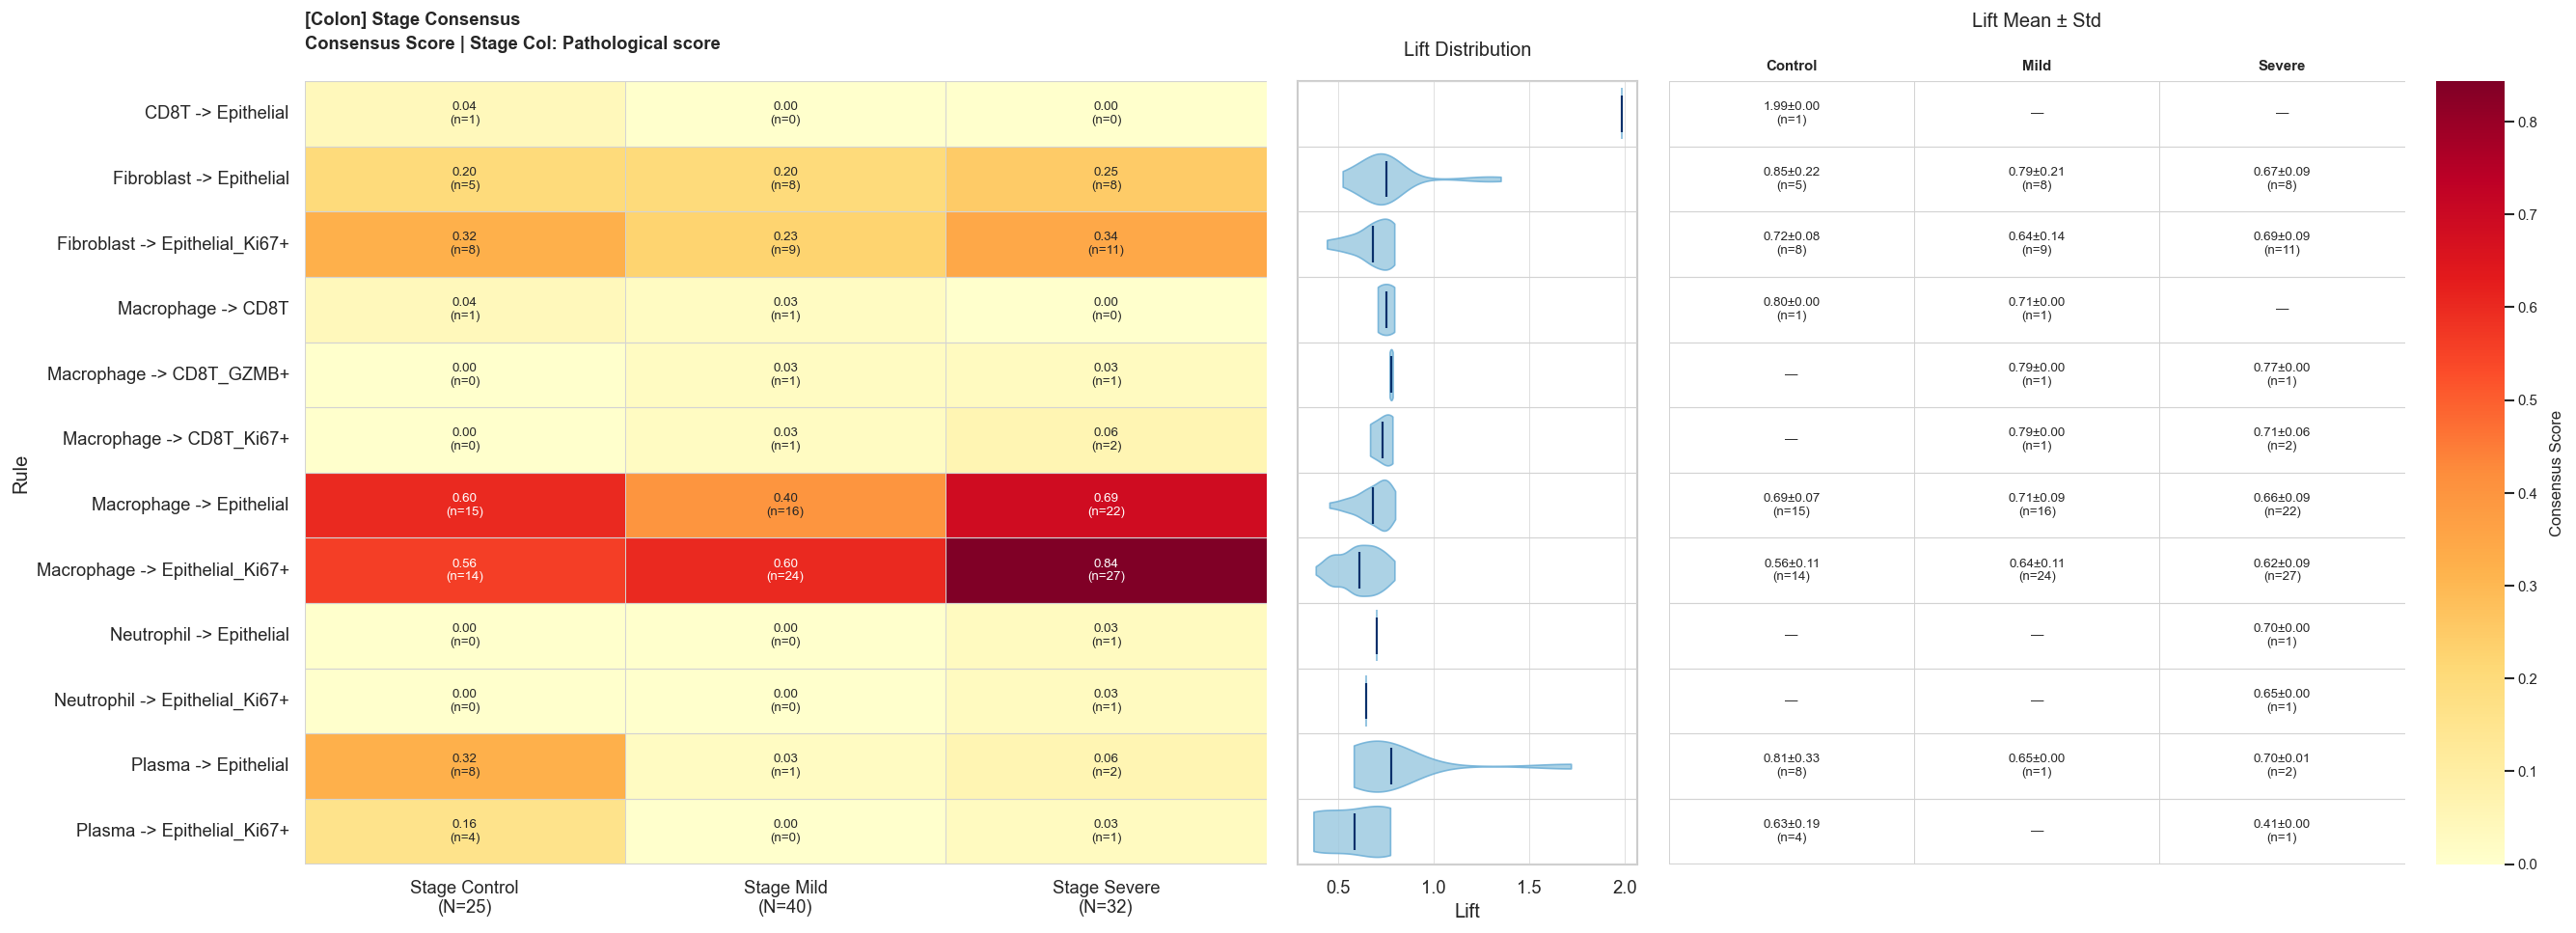

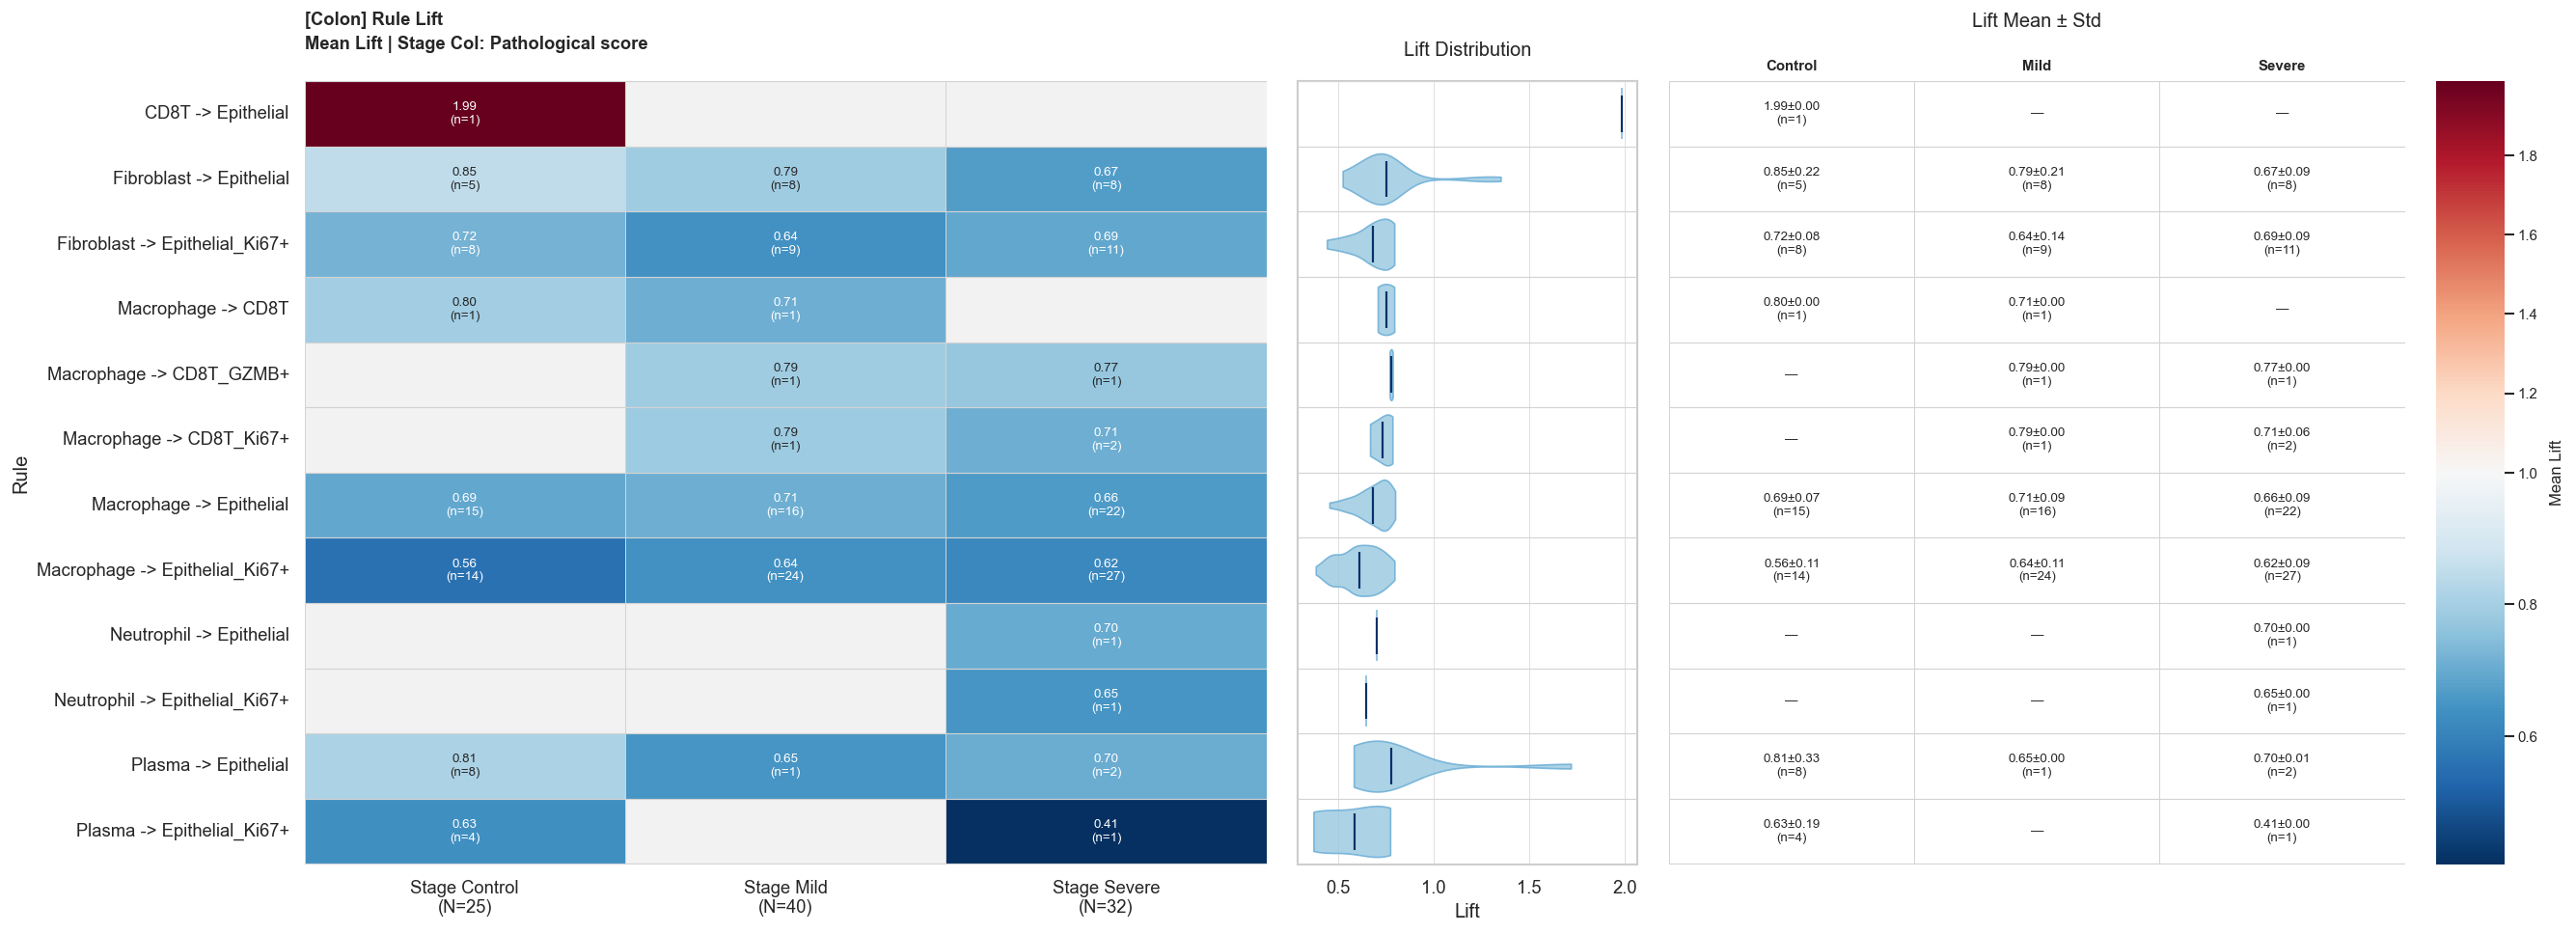


Organ: Duodenum


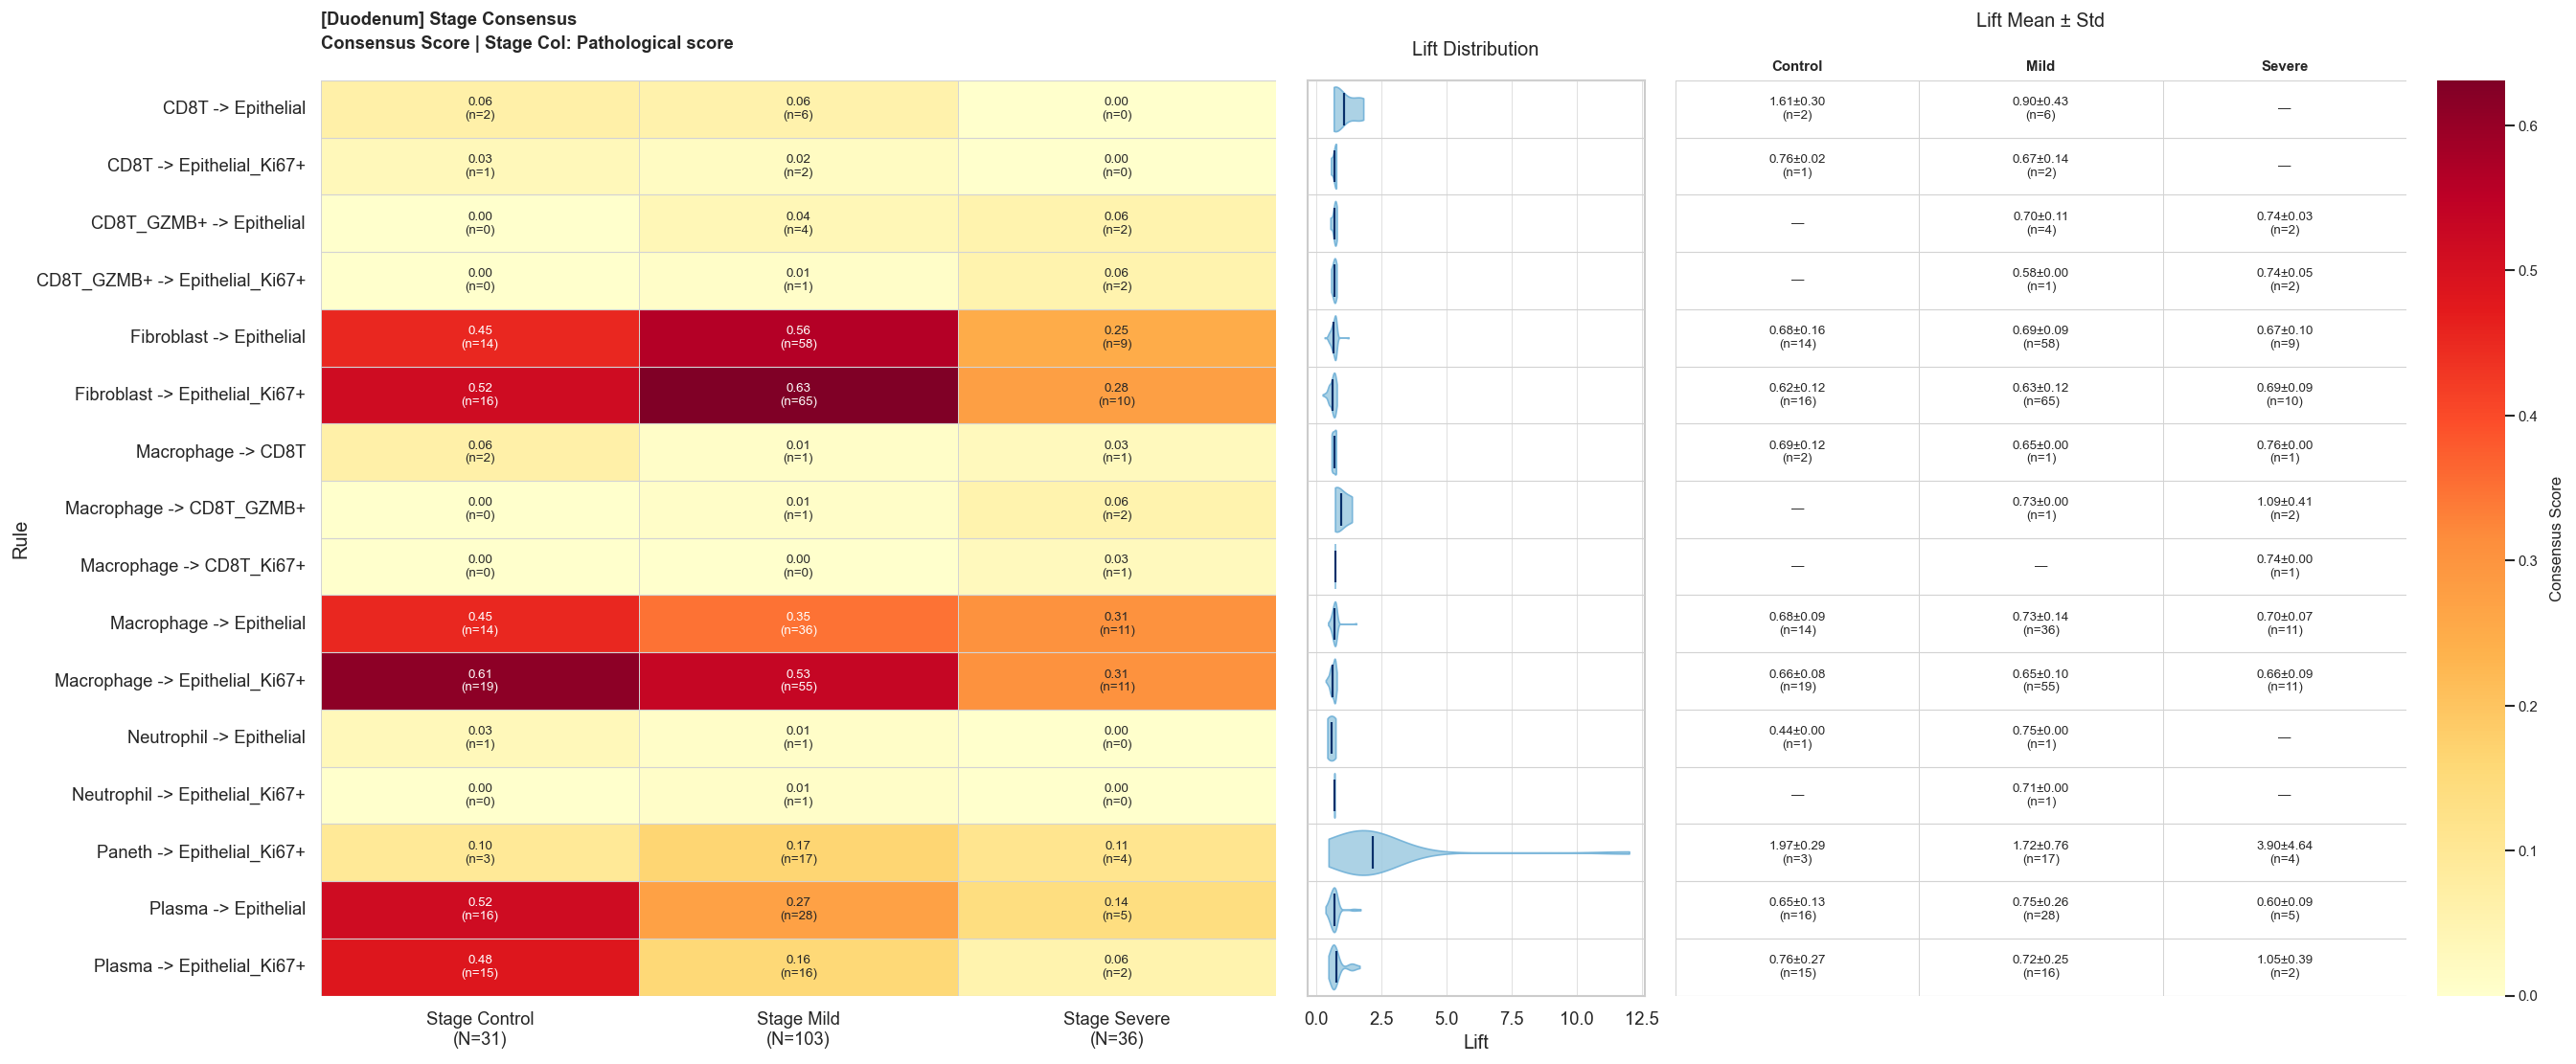

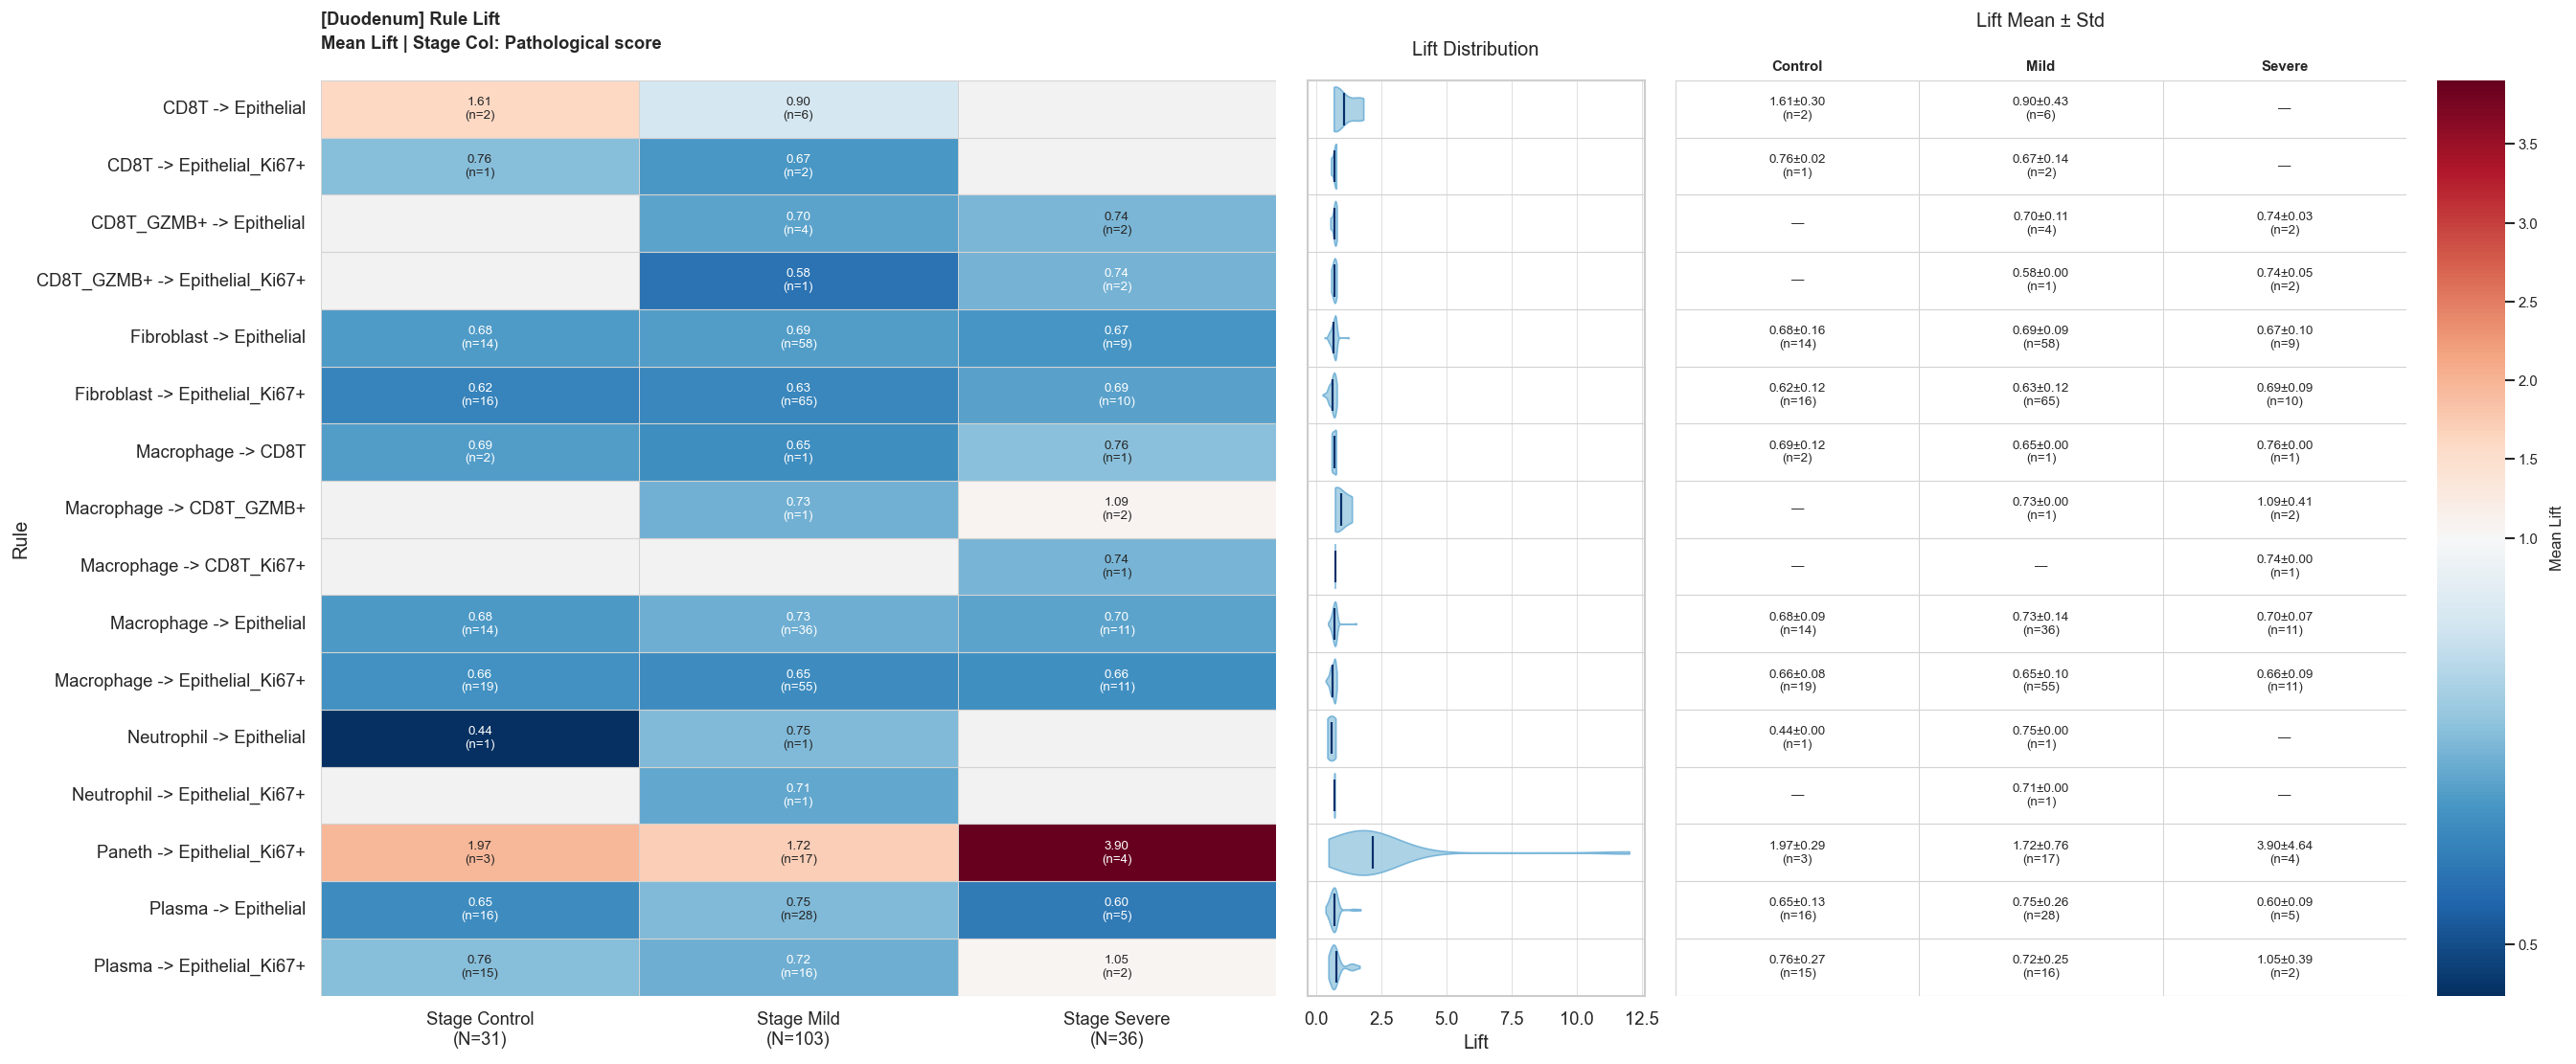

In [ ]:
def build_stage_consensus(work_df):
    stage_rule_counts = work_df.groupby([STAGE_COLUMN, "Rule"], as_index=False, observed=True)["FOV"].nunique()
    stage_rule_counts = stage_rule_counts.rename(columns={"FOV": "FOV_Count"})
    
    # Use the pre-calculated global total FOVs we attached in load_and_filter_data
    denominators = work_df[[STAGE_COLUMN, "Total_FOVs_In_Stage"]].drop_duplicates().set_index(STAGE_COLUMN)
    stage_rule_counts["Total_FOVs_In_Stage"] = stage_rule_counts[STAGE_COLUMN].map(denominators["Total_FOVs_In_Stage"]).astype(float)
    
    stage_rule_counts["Consensus_Score"] = stage_rule_counts["FOV_Count"] / stage_rule_counts["Total_FOVs_In_Stage"]
    return stage_rule_counts.sort_values(["Consensus_Score", "FOV_Count"], ascending=[False, False]).reset_index(drop=True)

def plot_for_organ(work_df, organ_name):
    print(f"\n{'='*60}\nOrgan: {organ_name}\n{'='*60}")
    organ_df = work_df[work_df["Organ"] == organ_name].copy()
    if organ_df.empty:
        print(f"No rules matched the target criteria for {organ_name}.")
        return
        
    stage_consensus_df = build_stage_consensus(organ_df)
    
    # Ensure there's data to plot
    if stage_consensus_df.empty:
        print(f"No consensus data computed for {organ_name}.")
        return

    # --- Consensus Plot ---
    stage_scores = stage_consensus_df.groupby(["Rule", STAGE_COLUMN], as_index=False)["Consensus_Score"].max()
    score_matrix = stage_scores.pivot(index="Rule", columns=STAGE_COLUMN, values="Consensus_Score").fillna(0)
    
    heatmap_cmap = show_zero_values_as_gray("YlOrRd")
    fig_consensus = plot_rule_stage_panels(
        score_matrix=score_matrix,
        metadata_df=organ_df,
        stage_count_rows=stage_consensus_df,
        metadata_value_col="Lift", # Use lift for the violin/table plots even in consensus view
        heatmap_cmap=heatmap_cmap,
        colorbar_label="Consensus Score",
        title_prefix=f"[{organ_name}] Stage Consensus"
    )
    plt.show()
    
    # --- Lift Plot ---
    lift_scores = organ_df.groupby(["Rule", STAGE_COLUMN], as_index=False)["Lift"].mean()
    lift_matrix = lift_scores.pivot(index="Rule", columns=STAGE_COLUMN, values="Lift")
    lift_matrix = lift_matrix.replace(0, np.nan)
    
    lift_cmap = show_zero_values_as_gray("RdBu_r")
    fig_lift = plot_rule_stage_panels(
        score_matrix=lift_matrix,
        metadata_df=organ_df,
        stage_count_rows=stage_consensus_df,
        heatmap_cmap=lift_cmap,
        metadata_value_col="Lift",
        colorbar_label="Mean Lift",
        heatmap_center=1.0, 
        title_prefix=f"[{organ_name}] Rule Lift"
    )
    plt.show()

if not filtered_df.empty:
    for organ in ["Colon", "Duodenum"]:
        plot_for_organ(filtered_df, organ)
